In [3]:
import pandas as pd

# 读取合同数据
df_contracts = pd.read_csv(r'C:\Users\Administrator\Desktop\pistons_contracts.csv')

# 算年均薪资AAV
df_contracts['AAV'] = df_contracts['VALUE'] / df_contracts['YRS']

print(df_contracts[['Player', 'AAV']].sort_values('AAV', ascending=False))

               Player          AAV
0     Cade Cunningham  53817156.00
3       Tobias Harris  26000000.00
1       Kevin Huerter  16250000.00
4     Duncan Robinson  15992957.00
2      Isaiah Stewart  15000000.00
7        Caris LeVert  14456600.00
5      Ron Holland II   9365845.75
6      Ausar Thompson   9061601.25
13      Malik Beasley   6000000.00
10          Paul Reed   5469291.50
8         Jalen Duren   4868736.00
12     Daniss Jenkins   3904762.00
9       Marcus Sasser   3366205.75
14      Javonte Green   2874436.00
11        Chaz Lanier   2171346.50
15     Tolu Smith III   1240864.00
16        Isaac Jones   1100000.00
17  Wendell Moore Jr.   1100000.00


In [4]:
# 读取活塞队表现数据
df_players = pd.read_csv(r'C:\Users\Administrator\Desktop\pistons.csv')
df_players = df_players[df_players['Player'] != 'Team Totals'].copy()

# 合并合同和表现数据
df_merged = df_contracts.merge(df_players[['Player', 'PTS', 'eFG%', 'MP', 'G']], on='Player', how='left')

print(df_merged[['Player', 'AAV', 'PTS', 'eFG%']].sort_values('AAV', ascending=False))

               Player          AAV   PTS   eFG%
0     Cade Cunningham  53817156.00  26.1  0.521
3       Tobias Harris  26000000.00  13.7  0.534
1       Kevin Huerter  16250000.00   NaN    NaN
4     Duncan Robinson  15992957.00   NaN    NaN
2      Isaiah Stewart  15000000.00   6.0  0.586
7        Caris LeVert  14456600.00   NaN    NaN
5      Ron Holland II   9365845.75   NaN    NaN
6      Ausar Thompson   9061601.25  10.1  0.547
13      Malik Beasley   6000000.00  16.3  0.579
10          Paul Reed   5469291.50   4.1  0.535
8         Jalen Duren   4868736.00  11.8  0.692
12     Daniss Jenkins   3904762.00   1.0  0.350
9       Marcus Sasser   3366205.75   6.6  0.561
14      Javonte Green   2874436.00   NaN    NaN
11        Chaz Lanier   2171346.50   NaN    NaN
15     Tolu Smith III   1240864.00   NaN    NaN
16        Isaac Jones   1100000.00   NaN    NaN
17  Wendell Moore Jr.   1100000.00   3.2  0.500


In [5]:
# 算每百万美元能买到多少得分
df_merged['AAV_M'] = df_merged['AAV'] / 1000000  # 单位换成百万美元
df_merged['PTS_per_M'] = df_merged['PTS'] / df_merged['AAV_M']  # 每百万美元得分

# 只看有数据的球员
df_value = df_merged.dropna(subset=['PTS', 'PTS_per_M']).copy()

print(df_value[['Player', 'AAV_M', 'PTS', 'PTS_per_M']].sort_values('PTS_per_M', ascending=False))

               Player      AAV_M   PTS  PTS_per_M
17  Wendell Moore Jr.   1.100000   3.2   2.909091
13      Malik Beasley   6.000000  16.3   2.716667
8         Jalen Duren   4.868736  11.8   2.423627
9       Marcus Sasser   3.366206   6.6   1.960664
6      Ausar Thompson   9.061601  10.1   1.114593
10          Paul Reed   5.469291   4.1   0.749640
3       Tobias Harris  26.000000  13.7   0.526923
0     Cade Cunningham  53.817156  26.1   0.484975
2      Isaiah Stewart  15.000000   6.0   0.400000
12     Daniss Jenkins   3.904762   1.0   0.256098


In [6]:
# 重新合并，加入防守数据
df_merged2 = df_contracts.merge(
    df_players[['Player', 'PTS', 'eFG%', 'MP', 'G', 'STL', 'BLK', 'DRB']], 
    on='Player', how='left'
)

df_merged2['AAV_M'] = df_merged2['AAV'] / 1000000
df_merged2['PTS_per_M'] = df_merged2['PTS'] / df_merged2['AAV_M']

df_value2 = df_merged2.dropna(subset=['PTS', 'STL', 'BLK']).copy()

print(df_value2[['Player', 'POS', 'AAV_M', 'PTS', 'STL', 'BLK', 'DRB']].sort_values('AAV_M', ascending=False))

               Player POS      AAV_M   PTS  STL  BLK  DRB
0     Cade Cunningham  PG  53.817156  26.1  1.0  0.8  5.3
3       Tobias Harris  PF  26.000000  13.7  1.0  0.8  5.0
2      Isaiah Stewart   C  15.000000   6.0  0.4  1.4  3.7
6      Ausar Thompson  SG   9.061601  10.1  1.7  0.7  3.3
13      Malik Beasley  SG   6.000000  16.3  0.9  0.1  2.0
10          Paul Reed   C   5.469291   4.1  0.9  0.6  1.8
8         Jalen Duren   C   4.868736  11.8  0.7  1.1  6.8
12     Daniss Jenkins   G   3.904762   1.0  0.0  0.0  0.3
9       Marcus Sasser  PG   3.366206   6.6  0.6  0.1  0.9
17  Wendell Moore Jr.  SG   1.100000   3.2  0.5  0.2  1.7


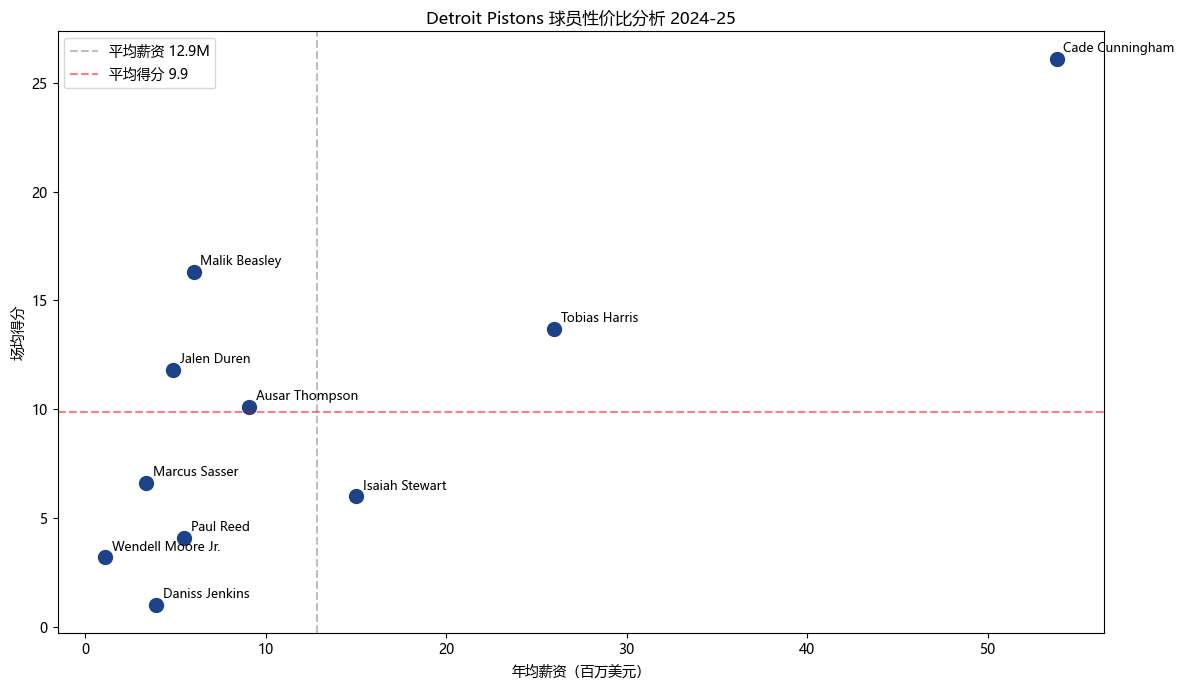

In [8]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12, 7))

# 画散点图，横轴AAV，纵轴得分
ax.scatter(df_value2['AAV_M'], df_value2['PTS'], color='#1d428a', s=100)

# 加球员名字标签
for i, row in df_value2.iterrows():
    ax.annotate(row['Player'], (row['AAV_M'], row['PTS']), 
                textcoords='offset points', xytext=(5, 5), fontsize=9)

# 加联盟平均线参考
avg_aav = df_value2['AAV_M'].mean()
avg_pts = df_value2['PTS'].mean()
ax.axvline(x=avg_aav, color='gray', linestyle='--', alpha=0.5, label=f'平均薪资 {avg_aav:.1f}M')
ax.axhline(y=avg_pts, color='red', linestyle='--', alpha=0.5, label=f'平均得分 {avg_pts:.1f}')

ax.set_xlabel('年均薪资（百万美元）')
ax.set_ylabel('场均得分')
ax.set_title('Detroit Pistons 球员性价比分析 2024-25')
ax.legend()

plt.tight_layout()
plt.show()

## 球员性价比分析结论

### 超值合同
- **Jalen Duren**：年均487万，BLK 1.1、DRB 6.8，内线防守贡献突出，是全队性价比最高的合同
- **Malik Beasley**：年均600万，得分16.3分，小合同高产出

### 问题合同
- **Tobias Harris**：年均2600万，得分13.7分，防守平庸，31岁无成长空间，是球队最大的合同包袱
- **Isaiah Stewart**：年均1500万，得分仅6分，虽有防守贡献（BLK 1.4）但薪资偏高

### 分析局限性
本分析基于基础统计数据（得分、篮板、盖帽），无法量化挡拆质量、无球跑动等隐性贡献，完整评估需要SportVU追踪数据支撑。

### 管理层建议
- 优先续约Duren（合同2025年到期），他是球队最超值的核心资产
- Harris合同2025年到期自然结束，不建议续约
- 围绕Cade和Duren重建内外线搭档体系